In [1]:
# import packages and the shared BTMS_model solver

import os
import sys
import io
import contextlib
import itertools
import importlib
import time
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import CoolProp.CoolProp as CP

from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

PROJECT_ROOT = os.path.abspath("../..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import lib.BTMS_model as BTMS_model

BTMS_model = importlib.reload(BTMS_model)

CASE_ID = 'C0002'
REVISION = 'R01'
RESULT_ID = f'{CASE_ID}{REVISION}'

SCENARIO_CODE = 'PARK25'
BTMS_CODE = 'LC'
MODEL_CODE = '1D'
TASK_CODE = 'VAL'


DATA_INPUT_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RESULTS_DIR = os.path.join(PROJECT_ROOT, 'out', CASE_ID)

os.makedirs(DATA_RESULTS_DIR, exist_ok=True)

RESULT_BASENAME = f'{RESULT_ID}_{SCENARIO_CODE}_{BTMS_CODE}_{MODEL_CODE}_{TASK_CODE}'
RESULT_FIGURE_PATH = os.path.join(DATA_RESULTS_DIR, f'{RESULT_BASENAME}.png')
NOTEBOOK_NAME = f'{RESULT_BASENAME}.ipynb'


# ------------------------------------------------------------
# Check paths and file names
# ------------------------------------------------------------

print(f'Project root: {PROJECT_ROOT}')
print(f'BTMS_model loaded from: {BTMS_model.__file__}')
print(f'Data input directory: {DATA_INPUT_DIR}')
print(f'Result basename: {RESULT_BASENAME}')
print(f'Result figure path: {RESULT_FIGURE_PATH}')

Project root: d:\Users\liu\Desktop\eBATS_minor fixes
BTMS_model loaded from: d:\Users\liu\Desktop\eBATS_minor fixes\lib\BTMS_model.py
Data input directory: d:\Users\liu\Desktop\eBATS_minor fixes\data
Result basename: C0002R01_PARK25_LC_1D_VAL
Result figure path: d:\Users\liu\Desktop\eBATS_minor fixes\out\C0002\C0002R01_PARK25_LC_1D_VAL.png


In [2]:
# read Qbat(W) using the same time relation as C0003R00_PARK25_LC_1D_SCAN

SIM_DURATION_S = 1920.0   # s, physical mission duration
dt = 1.0                 # s, integration time step

NUM_STEPS = int(round(SIM_DURATION_S / dt))
if not np.isclose(NUM_STEPS * dt, SIM_DURATION_S):
    raise ValueError('SIM_DURATION_S must be an integer multiple of dt.')

# Keep the same downstream variable name as the parameter-scan notebook.
SIM_TIME_S = NUM_STEPS

HEAT_INPUT_FILE = os.path.join(
    DATA_INPUT_DIR,
    'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx'
)

heat_input_df = pd.read_excel(HEAT_INPUT_FILE, sheet_name='Sheet1')
power_generation_data_1s = heat_input_df['Qbat(W)'].dropna().to_numpy(dtype=float)

if len(power_generation_data_1s) == 0:
    raise ValueError('No valid Qbat(W) data were found in the heat-input file.')

# The source data are 1-s single-cell heat-generation values.
time_s = np.arange(SIM_TIME_S + 1) * dt
power_indices = np.floor(time_s[:-1]).astype(int)
power_indices = np.clip(power_indices, 0, len(power_generation_data_1s) - 1)
power_generation_data = power_generation_data_1s[power_indices]

print(f'Heat-input file: {HEAT_INPUT_FILE}')
print(f'Simulation duration: {SIM_DURATION_S:.1f} s')
print(f'Time step dt: {dt:.3f} s')
print(f'Number of numerical steps: {SIM_TIME_S}')
print(f'Q_gen array length: {len(power_generation_data)}')
print(
    f'Q_cell range: min={np.min(power_generation_data):.6g} W, '
    f'max={np.max(power_generation_data):.6g} W, '
    f'mean={np.mean(power_generation_data):.6g} W'
)


Heat-input file: d:\Users\liu\Desktop\eBATS_minor fixes\data\MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx
Simulation duration: 1920.0 s
Time step dt: 1.000 s
Number of numerical steps: 1920
Q_gen array length: 1920
Q_cell range: min=0.0201991 W, max=4.15314 W, mean=0.671994 W


In [3]:
# baseline rectangular liquid-cooling case
# The physical and numerical relations are consistent with
# the baseline design obtained from C0001R01_PARK25_LC_EPSNTU_SIZ.

BATTERY_PROPS = {
    'm_bat': 48e-3,          # kg, single-cell mass
    'cp_bat': 830.0,         # J/(kg K), single-cell specific heat
    'D_bat': 18e-3,          # m, cell diameter
    'H_bat': 65e-3,          # m, cell height
}

MODULE_LAYOUT = {
    'N_r': 20,               # control volumes along coolant-flow direction
    'N_c': 16,               # physical cells in transverse direction
}

LIQUID_SETTINGS = {
    'fluid': 'Water',
    'p_water': 101325.0,     # Pa

    # Baseline rectangular-channel geometry
    'W_channel': 16.0e-3,     # m, channel width
    'H_channel': 6.25e-3,     # m, channel height
    'L_channel': 0.3884749,   # m, channel length
    'num_channel': 20,       # number of parallel channels

    # Cold-plate properties
    'plate_thickness': 2.0e-3,  # m, conduction thickness
    'k_plate': 200.0,            # W/(m K)

    # Water properties used in baseline sizing
    'rho_water': 997.0,          # kg/m3
    'mu_water': 0.00089,         # Pa s
    'cp_water': 4180.0,          # J/(kg K)
    'k_water': 0.606,            # W/(m K)
}

SOLVER_SETTINGS = {
    'solver_tol': 1e-6,
    'solver_maxiter': 1000,
}

VALIDATION_CASE = {
    # Total flow through all 20 parallel channels
    'm_dot_total': 0.06106836,   # kg/s

    # Coolant inlet temperature
    'T_water': 25.0,             # degC
}

m_bat = BATTERY_PROPS['m_bat']
cp_bat = BATTERY_PROPS['cp_bat']
D_bat = BATTERY_PROPS['D_bat']
H_bat = BATTERY_PROPS['H_bat']

N_r = MODULE_LAYOUT['N_r']
N_c = MODULE_LAYOUT['N_c']

num_seg = N_r
N_cells_physical = N_r * N_c

fluid = LIQUID_SETTINGS['fluid']
p_water = LIQUID_SETTINGS['p_water']

W_channel = LIQUID_SETTINGS['W_channel']
H_channel = LIQUID_SETTINGS['H_channel']
L_channel = LIQUID_SETTINGS['L_channel']
num_parallel_channel = LIQUID_SETTINGS['num_channel']

plate_thickness = LIQUID_SETTINGS['plate_thickness']
k_plate = LIQUID_SETTINGS['k_plate']

rho_water = LIQUID_SETTINGS['rho_water']
mu_water = LIQUID_SETTINGS['mu_water']
cp_water = LIQUID_SETTINGS['cp_water']
k_water = LIQUID_SETTINGS['k_water']

solver_tol = SOLVER_SETTINGS['solver_tol']
solver_maxiter = SOLVER_SETTINGS['solver_maxiter']

m_dot_total = float(
    VALIDATION_CASE['m_dot_total']
)

T_water = float(
    VALIDATION_CASE['T_water']
)

# The 1D thermal model solves one representative parallel channel.
m_dot = (
    m_dot_total
    / num_parallel_channel
)

# Equivalent transverse-cell number assigned to one channel.
num_cell_seg = (
    N_c
    / num_parallel_channel
)

if num_cell_seg <= 0:
    raise ValueError(
        'num_cell_seg must be positive.'
    )

print('Baseline rectangular liquid-cooling case loaded.')
print(f'num_seg = {num_seg}')
print(f'Physical cells in full module = {N_cells_physical}')
print(f'Parallel channels = {num_parallel_channel}')
print(f'W_channel = {W_channel * 1000.0:.2f} mm')
print(f'H_channel = {H_channel * 1000.0:.2f} mm')
print(f'L_channel = {L_channel * 1000.0:.2f} mm')
print(f'm_dot_total = {m_dot_total:.8f} kg/s')
print(f'm_dot_channel = {m_dot:.8f} kg/s')
print(f'T_water = {T_water:.2f} degC')
print(f'num_cell_seg = {num_cell_seg:.6g}')

Baseline rectangular liquid-cooling case loaded.
num_seg = 20
Physical cells in full module = 320
Parallel channels = 20
W_channel = 16.00 mm
H_channel = 6.25 mm
L_channel = 388.47 mm
m_dot_total = 0.06106836 kg/s
m_dot_channel = 0.00305342 kg/s
T_water = 25.00 degC
num_cell_seg = 0.8


In [4]:
# calculate water properties, channel geometry,
# and heat-transfer coefficient

T_water_K = T_water + 273.15

mu_water = CP.PropsSI('V','T', T_water_K,'P', p_water,fluid)
rho_water = CP.PropsSI('D','T', T_water_K,'P', p_water,fluid)
cp_water = CP.PropsSI('C','T', T_water_K,'P', p_water,fluid)
k_water = CP.PropsSI('L','T', T_water_K,'P', p_water,fluid)
Pr_water = (cp_water* mu_water/ k_water)

# Cross-sectional area of one rectangular channel
A_cool_cs = (W_channel* H_channel)

# Hydraulic diameter of one rectangular channel
D_h = (2.0* W_channel* H_channel/ (W_channel + H_channel))

# Heat-transfer area of one channel segment
A_HT_seg = ((W_channel + 2.0 * H_channel)* L_channel/ num_seg)
# Coolant velocity in one channel
u_water = (m_dot/ (rho_water * A_cool_cs))

# Reynolds number based on hydraulic diameter
Re_water = (rho_water* u_water* D_h/ mu_water)

# Rectangular-channel Nusselt number
Nu_water = BTMS_model.liquid_nusselt_number_rect_channel(
    W_channel,
    H_channel
)

# Convective heat-transfer coefficient
h_water = (Nu_water* k_water/ D_h)

# Conduction resistance of the cold plate
R_plate = (plate_thickness/ k_plate)

# Overall heat-transfer coefficient
htc_global = 1.0 / (
    1.0 / h_water
    + R_plate
)

htc_cool = (
    np.ones(num_seg)
    * htc_global
)

print('Liquid-cooling properties calculated.')
print(f'rho_water = {rho_water:.4f} kg/m3')
print(f'cp_water = {cp_water:.4f} J/(kg K)')
print(f'mu_water = {mu_water:.6e} Pa s')
print(f'k_water = {k_water:.6f} W/(m K)')
print(f'Pr_water = {Pr_water:.4f}')
print(f'W_channel = {W_channel * 1000.0:.3f} mm')
print(f'H_channel = {H_channel * 1000.0:.3f} mm')
print(f'D_h = {D_h * 1000.0:.4f} mm')
print(f'A_cool_cs = {A_cool_cs:.6e} m2')
print(f'A_HT_seg = {A_HT_seg:.6e} m2')
print(f'u_water = {u_water:.6f} m/s')
print(f'Re_water = {Re_water:.3f}')
print(f'Nu_water = {Nu_water:.3f}')
print(f'h_water = {h_water:.3f} W/(m2 K)')
print(f'htc_global = {htc_global:.3f} W/(m2 K)')


Liquid-cooling properties calculated.
rho_water = 997.0476 kg/m3
cp_water = 4181.3150 J/(kg K)
mu_water = 8.900225e-04 Pa s
k_water = 0.606516 W/(m K)
Pr_water = 6.1358
W_channel = 16.000 mm
H_channel = 6.250 mm
D_h = 8.9888 mm
A_cool_cs = 1.000000e-04 m2
A_HT_seg = 5.535767e-04 m2
u_water = 0.030625 m/s
Re_water = 308.379
Nu_water = 4.936
h_water = 333.027 W/(m2 K)
htc_global = 331.922 W/(m2 K)


In [5]:
# solve the baseline rectangular liquid-cooling case
# by calling BTMS_model

start_time = time.time()
progress_interval = 50

# Initial battery temperature follows the parameter-scan relationship:
# T_bat_init = T_water_in.
T_bat = np.ones(num_seg) * T_water
T_cool = np.ones(num_seg) * T_water

T_bat_history = np.zeros((SIM_TIME_S + 1, num_seg))
T_water_history = np.zeros((SIM_TIME_S + 1, num_seg))
T_bat_history[0, :] = T_bat
T_water_history[0, :] = T_cool

# These arrays store energy over each numerical step because
# BTMS_model.cal_energy_balance multiplies heat rates by dt.
Q_bat_history_J = np.zeros(SIM_TIME_S + 1)
Q_cool_history_J = np.zeros(SIM_TIME_S + 1)
Q_res_history_J = np.zeros(SIM_TIME_S + 1)

print(f'Total time steps to solve: {SIM_TIME_S}')
print(f'Progress interval: {progress_interval} step(s)')

for k in range(SIM_TIME_S):
    t = time_s[k]
    is_cool = True

    args = {
        'num_seg': num_seg,
        'num_seg_bat': num_seg,
        'dt': dt,
        'T_cool_pre': T_cool,
        'T_bat_pre': T_bat,
        'u_cool_in': u_water,
        'p_cool': p_water,
        'fluid_cool': fluid,
        'A_HT_seg': A_HT_seg,
        'A_cool_cs': A_cool_cs,
        'm_bat': m_bat,
        'cp_bat': cp_bat,
        'D_bat': D_bat,
        'T_cool_in': T_water,
        'T_cool_out': max(float(T_cool[-1]), T_water),
        'is_cool': is_cool,
        'htc_cool': htc_cool,
        'cp_cool': cp_water,
        'rho_cool': rho_water,
        'Q_gen': power_generation_data[k],
        'num_cell_seg': num_cell_seg,
        'debug': False,
    }

    try:
        with contextlib.redirect_stdout(io.StringIO()):
            T_dist = BTMS_model.solve_coolant_temperature_distribution(
                args,
                tol=solver_tol,
                maxiter=solver_maxiter,
                debug=False
            )
    except Exception as exc:
        print('\nSolver failed in the validation case.')
        print(f'time step k = {k}')
        print(f't = {t:.1f} s')
        print(f'Q_gen = {power_generation_data[k]} W/cell')
        print(f'm_dot_channel = {m_dot} kg/s')
        print(f'T_water = {T_water} degC')
        print(f'num_cell_seg = {num_cell_seg}')
        print(f'u_water = {u_water}')
        print(f'Re_water = {Re_water}')
        print(f'Nu_water = {Nu_water}')
        print(f'htc_global = {htc_global}')
        print(f'A_HT_seg = {A_HT_seg}')
        print(f'A_cool_cs = {A_cool_cs}')
        print(f'T_bat_min/max before solve = {np.min(T_bat)}, {np.max(T_bat)}')
        print(f'T_cool_min/max before solve = {np.min(T_cool)}, {np.max(T_cool)}')
        print(f'error = {repr(exc)}')
        raise

    if not np.all(np.isfinite(T_dist)):
        raise FloatingPointError(
            f'Non-finite T_dist returned at k={k}, t={t:.1f} s.'
        )

    T_cool = T_dist[:num_seg]
    T_bat = T_dist[num_seg:]

    Q_cool_HT, Q_cool_change, Q_bat = BTMS_model.cal_energy_balance(
        T_dist,
        args
    )

    Q_bat_history_J[k + 1] = np.sum(Q_bat)
    Q_cool_history_J[k + 1] = np.sum(Q_cool_HT)

    Q_gen_model_J = (
        power_generation_data[k]
        * num_cell_seg
        * num_seg
        * dt
    )
    Q_res_history_J[k + 1] = abs(
        Q_gen_model_J - np.sum(Q_bat) - np.sum(Q_cool_HT)
    )

    T_bat_history[k + 1, :] = T_bat
    T_water_history[k + 1, :] = T_cool

    step_number = k + 1
    if (
        step_number == 1
        or step_number % progress_interval == 0
        or step_number == SIM_TIME_S
    ):
        elapsed = time.time() - start_time
        print(
            f'Step {step_number}/{SIM_TIME_S}, '
            f't={time_s[step_number]:.0f} s, '
            f'Tmax={np.max(T_bat):.4f} degC, '
            f'Tmin={np.min(T_bat):.4f} degC, '
            f'elapsed={elapsed:.1f} s',
            flush=True
        )

elapsed_total = time.time() - start_time
print('Transient validation simulation finished.')
print(f'Elapsed wall time = {elapsed_total:.2f} s')
print(f'Maximum energy residual = {np.max(Q_res_history_J):.6e} J')


Total time steps to solve: 1920
Progress interval: 50 step(s)
Step 1/1920, t=1 s, Tmax=25.0672 degC, Tmin=25.0671 degC, elapsed=0.2 s
Step 50/1920, t=50 s, Tmax=26.9151 degC, Tmin=26.8391 degC, elapsed=1.4 s
Step 100/1920, t=100 s, Tmax=27.1805 degC, Tmin=27.0048 degC, elapsed=2.4 s
Step 150/1920, t=150 s, Tmax=27.4055 degC, Tmin=27.1430 degC, elapsed=3.3 s
Step 200/1920, t=200 s, Tmax=27.4461 degC, Tmin=27.1106 degC, elapsed=4.5 s
Step 250/1920, t=250 s, Tmax=27.2706 degC, Tmin=26.8894 degC, elapsed=5.8 s
Step 300/1920, t=300 s, Tmax=27.1318 degC, Tmin=26.7266 degC, elapsed=6.9 s
Step 350/1920, t=350 s, Tmax=27.0257 degC, Tmin=26.6100 degC, elapsed=8.1 s
Step 400/1920, t=400 s, Tmax=26.9467 degC, Tmin=26.5289 degC, elapsed=9.1 s
Step 450/1920, t=450 s, Tmax=26.8893 degC, Tmin=26.4739 degC, elapsed=10.1 s
Step 500/1920, t=500 s, Tmax=26.8484 degC, Tmin=26.4376 degC, elapsed=11.1 s
Step 550/1920, t=550 s, Tmax=26.8198 degC, Tmin=26.4142 degC, elapsed=12.1 s
Step 600/1920, t=600 s, Tmax=

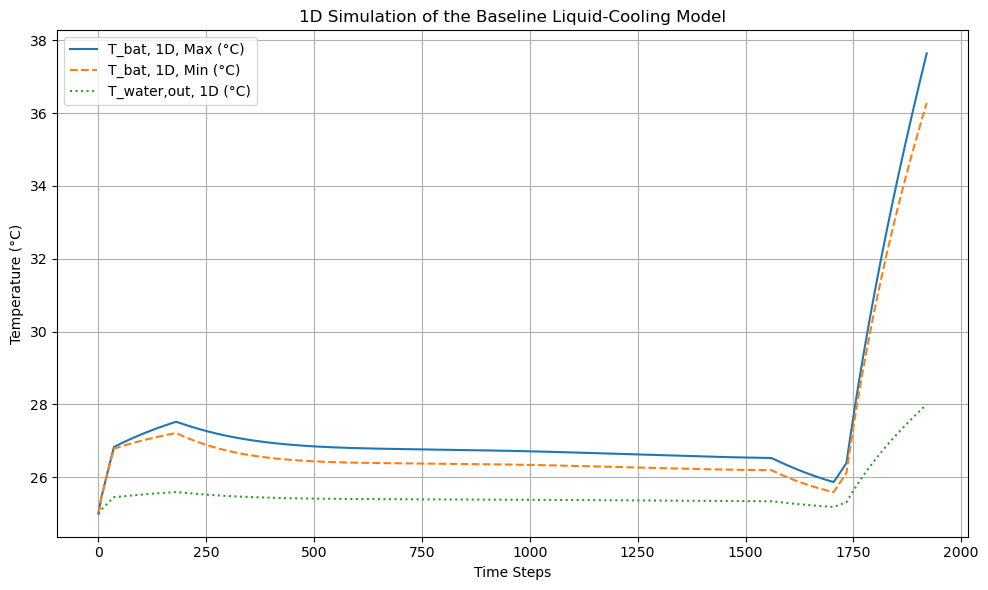

Tmax_mission = 37.6394 degC
Tmin_mission = 25.0000 degC
DeltaT_mission_max = 1.3621 degC
Twater_out_max = 28.0035 degC
Saved figure: d:\Users\liu\Desktop\eBATS_minor fixes\out\C0002\C0002R01_PARK25_LC_1D_VAL.png


In [6]:
# calculate indicators and save the temperature figure

Tmax_1D = np.max(T_bat_history, axis=1)
Tmin_1D = np.min(T_bat_history, axis=1)
DeltaT_1D = Tmax_1D - Tmin_1D
Twater_out_1D = T_water_history[:, -1]

# Use the same plotting style as the reference BTMS T Solver notebook.
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))
plt.plot(time_s, Tmax_1D, label='T_bat, 1D, Max (°C)', linestyle='-')
plt.plot(time_s, Tmin_1D, label='T_bat, 1D, Min (°C)', linestyle='--')
plt.plot(time_s, Twater_out_1D, label='T_water,out, 1D (°C)', linestyle=':')

plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.title('1D Simulation of the Baseline Liquid-Cooling Model')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    RESULT_FIGURE_PATH,
    dpi=600,
    bbox_inches='tight'
)
plt.show()

print(f'Tmax_mission = {np.max(Tmax_1D):.4f} degC')
print(f'Tmin_mission = {np.min(Tmin_1D):.4f} degC')
print(f'DeltaT_mission_max = {np.max(DeltaT_1D):.4f} degC')
print(f'Twater_out_max = {np.max(Twater_out_1D):.4f} degC')
print(f'Saved figure: {RESULT_FIGURE_PATH}')
